In [58]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

In [59]:
df = pd.read_csv('fuel_efficiency.csv')
df.head()

,speed_kmh,efficiency_kmpl
0,96.4,19.70
1,52.4,19.59
2,24.9,15.08
3,22.0,14.92
4,117.6,13.30


In [60]:
x = df[['speed_kmh']].to_numpy()
y = df['efficiency_kmpl'].to_numpy()
x.shape, y.shape

((50, 1), (50,))

In [61]:
# split
x_train, x_, y_train, y_ = train_test_split(x, y, test_size=0.4, random_state=1)
x_cv, x_test, y_cv, y_test = train_test_split(x_, y_, test_size=0.5, random_state=1)
del x_, y_

print(f"x_train: {x_train.shape}, y_train: {y_train.shape}")
print(f"x_cv: {x_cv.shape}, y_cv: {y_cv.shape}")
print(f"x_test: {x_test.shape}, y_test: {y_test.shape}")

x_train: (30, 1), y_train: (30,)
x_cv: (10, 1), y_cv: (10,)
x_test: (10, 1), y_test: (10,)


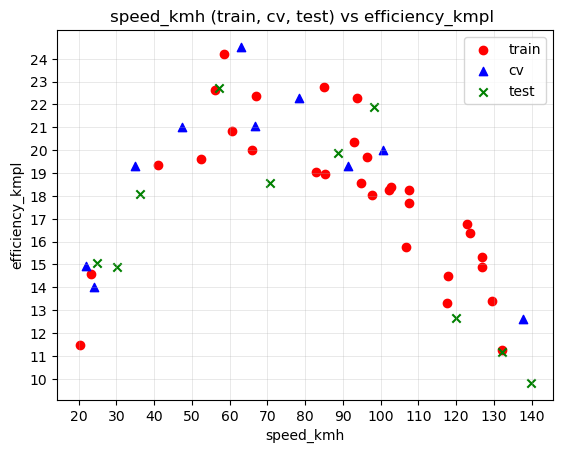

In [62]:
# plotting to visualize data
plt.scatter(x_train, y_train, marker="o", color="r", label="train")
plt.scatter(x_cv, y_cv, marker="^", color="b", label="cv")
plt.scatter(x_test, y_test, marker="x", color="g", label="test")
plt.xlabel("speed_kmh")
plt.ylabel("efficiency_kmpl")
plt.title("speed_kmh (train, cv, test) vs efficiency_kmpl ")
plt.legend()
plt.grid(alpha=0.4, linewidth=0.5)
plt.xticks(np.linspace(20, 140, 13))
plt.yticks(np.linspace(10, 24, 15))

plt.show()

In [63]:
baseline_train = y_train.mean()
baseline_cv = y_train.mean()

baseline_predictions_train = np.full(y_train.shape, baseline_train)
baseline_predictions_cv = np.full(y_cv.shape, baseline_cv)

j_baseline_train = mean_squared_error(baseline_predictions_train, y_train) / 2
j_baseline_cv = mean_squared_error(baseline_predictions_cv, y_cv) / 2

print(f"baseline train: {baseline_train}, baseline_cost: {j_baseline_train}")
print(f"baseline train: {baseline_cv}, baseline_cost: {j_baseline_cv}")

baseline train: 17.964666666666666, baseline_cost: 5.481919111111112
baseline train: 17.964666666666666, baseline_cost: 7.104314222222223


In [64]:
# finding best degree
degree_list = list(range(1, 11))
cost_train = []
cost_cv = []

for i in degree_list:
    # mapping for degree
    poly = PolynomialFeatures(degree = i, include_bias=False)
    x_train_mapped = poly.fit_transform(x_train)
    x_cv_mapped = poly.transform(x_cv)

    # scaling
    scaler = StandardScaler()
    x_train_scaled_mapped = scaler.fit_transform(x_train_mapped)
    x_cv_scaled_mapped = scaler.transform(x_cv_mapped)

    # training
    model = LinearRegression()
    model.fit(x_train_scaled_mapped, y_train)

    # making predictions
    prediction_train = model.predict(x_train_scaled_mapped)
    prediction_cv = model.predict(x_cv_scaled_mapped)

    # calculating cost
    cost_train.append((mean_squared_error(y_train, prediction_train) / 2.0))
    cost_cv.append((mean_squared_error(y_cv, prediction_cv) / 2))

cost_train = np.array(cost_train)
cost_cv = np.array(cost_cv)

In [65]:
for i in range(1, 11):
    print(f"degree: {i}, cost_train: {cost_train[i-1]}, cost_cv: {cost_cv[i-1]}")

degree: 1, cost_train: 4.82480850668952, cost_cv: 7.320196518980862
degree: 2, cost_train: 1.2762081944855184, cost_cv: 1.4618263941715566
degree: 3, cost_train: 1.009207933522012, cost_cv: 0.8756912761437103
degree: 4, cost_train: 0.9988475932033917, cost_cv: 0.8887224634589532
degree: 5, cost_train: 0.9964695556904258, cost_cv: 0.973232198770417
degree: 6, cost_train: 0.9418633619277603, cost_cv: 2.0687383603059986
degree: 7, cost_train: 0.9123202948554205, cost_cv: 4.507148858316294
degree: 8, cost_train: 0.7366186972251302, cost_cv: 27.373227077999644
degree: 9, cost_train: 0.7359584794454646, cost_cv: 30.446439441713785
degree: 10, cost_train: 0.7090116906503335, cost_cv: 5.575582947359752


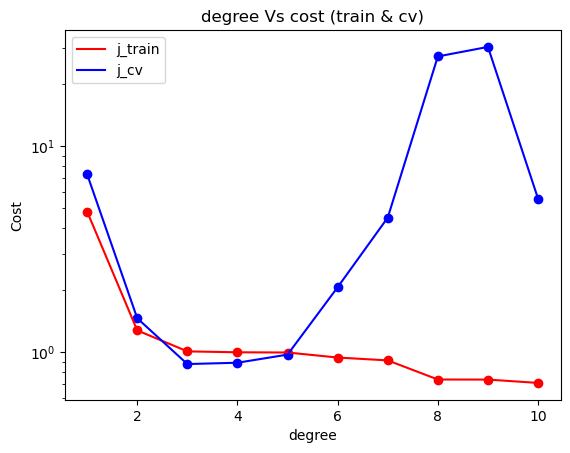

In [66]:
# plotting cost train and cv
plt.scatter(degree_list, cost_train, marker="o", color="r")
plt.plot(degree_list, cost_train, color="r", label="j_train")
plt.scatter(degree_list, cost_cv, marker="o", color="b")
plt.plot(degree_list, cost_cv, color="b", label="j_cv")
plt.title("degree Vs cost (train & cv)")
plt.xlabel("degree")
plt.ylabel("Cost")
plt.legend()
plt.yscale('log')
plt.show()


In [67]:
final_model_degree = cost_cv.argmin()+1
final_model_degree

np.int64(3)

In [68]:
# final model
poly = PolynomialFeatures(degree = final_model_degree, include_bias=False)
final_x_train_mapped = poly.fit_transform(x_train)

# scaling
scaler = StandardScaler()
final_x_train_scaled_mapped = scaler.fit_transform(final_x_train_mapped)

# training
model = LinearRegression()
model.fit(final_x_train_scaled_mapped, y_train)

# making predictions
predictions_on_train = model.predict(final_x_train_scaled_mapped)

final_train_cost = mean_squared_error(y_train, predictions_on_train) / 2.0
print(f"Train cost: {final_train_cost}")


print(f"Train r^2 score: {model.score(final_x_train_scaled_mapped, y_train)}")

Train cost: 1.009207933522012
Train r^2 score: 0.8159024398086276


In [69]:
x_test_mapped = poly.transform(x_test)
x_test_mapped_scaled = scaler.transform(x_test_mapped)

predictions_on_test = model.predict(x_test_mapped_scaled)

print(f"Test cost: {mean_squared_error(y_test, predictions_on_test) / 2}")
print(f"Score of r^2 test: {model.score(x_test_mapped_scaled, y_test)}")

Test cost: 1.9953001658306029
Score of r^2 test: 0.7767684769066932
